# ODE Numerical Methods — Results

See [README.md](README.md) for theory and method details.

## Simple Harmonic Oscillator — Predictor-Corrector (Euler-Trapezoidal)

Runs the simulation and plots position, velocity, absolute error vs exact solution $5\sin t$, and total energy over time. The phase portrait shows $v$ vs $x$.

In [29]:
import matplotlib.pyplot as plt
from simple_harmonic_oscillator_predictor_corrector import run_simulation

In [30]:
results = run_simulation()
t = results["time"]
x = results["position"]
v = results["velocity"]
err = results["error"]
E = results["energy"]

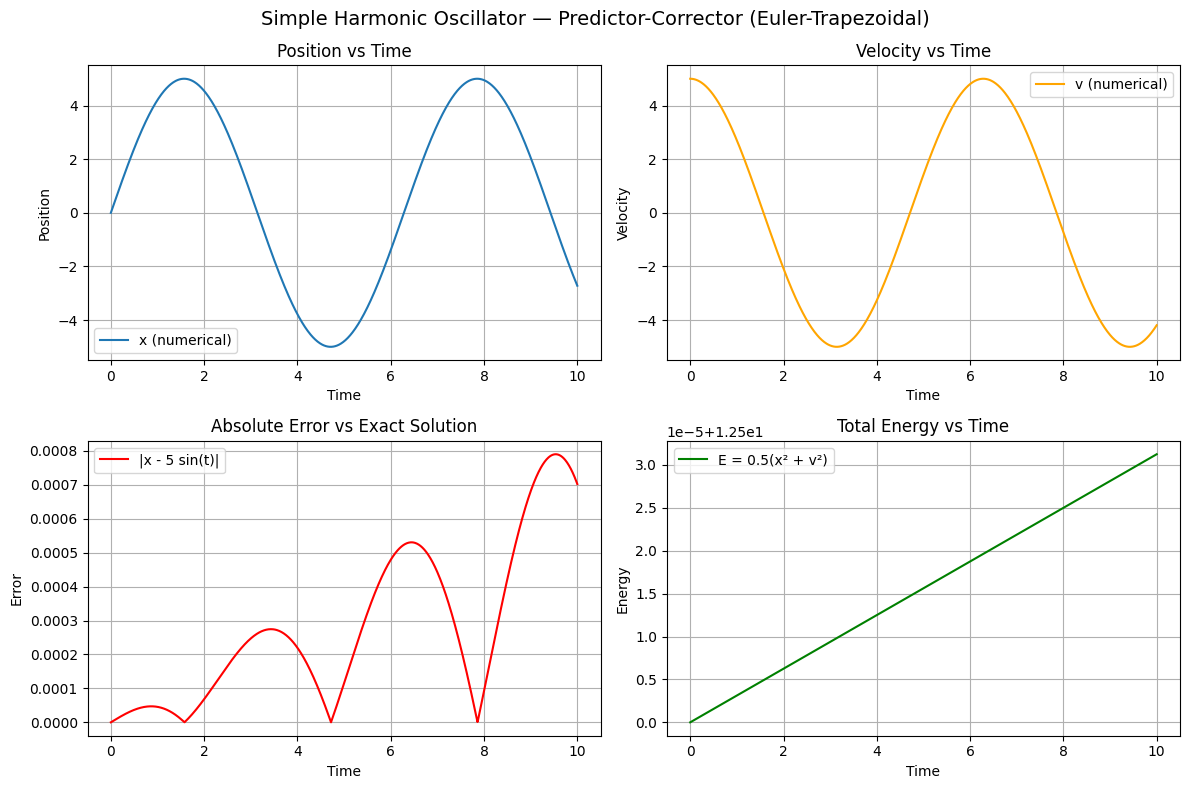

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Simple Harmonic Oscillator — Predictor-Corrector (Euler-Trapezoidal)", fontsize=14)

axes[0, 0].plot(t, x, label="x (numerical)")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Position")
axes[0, 0].set_title("Position vs Time")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(t, v, color="orange", label="v (numerical)")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Velocity")
axes[0, 1].set_title("Velocity vs Time")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(t, err, color="red", label="|x - 5 sin(t)|")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Error")
axes[1, 0].set_title("Absolute Error vs Exact Solution")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(t, E, color="green", label="E = 0.5(x² + v²)")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Energy")
axes[1, 1].set_title("Total Energy vs Time")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

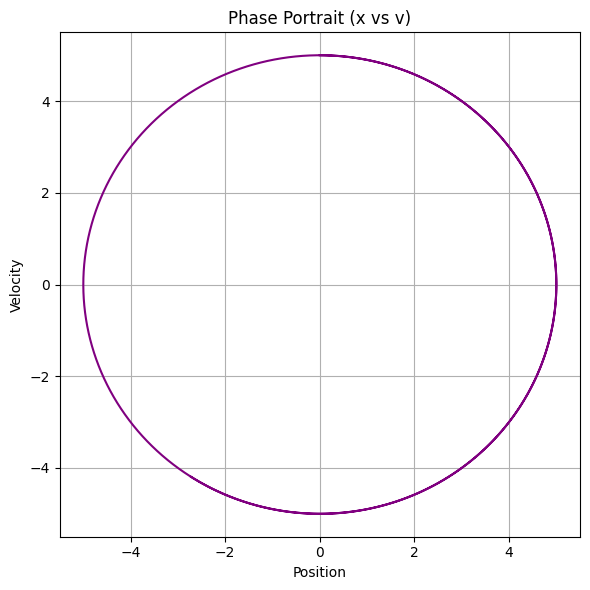

In [32]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x, v, color="purple")
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_title("Phase Portrait (x vs v)")
ax.grid(True)
plt.tight_layout()
plt.show()

## Leapfrog Method — $y' = y$

Runs the leapfrog integrator on $y' = y$ and plots the numerical solution vs exact $e^t$, and the pointwise absolute error.

In [33]:
from leap_frog_method import run_simulation as run_leapfrog

lf = run_leapfrog()
t_lf = lf["time"]
y_lf = lf["leapfrog"]
y_exact = lf["exact"]
err_lf = [abs(a - b) for a, b in zip(y_lf, y_exact)]

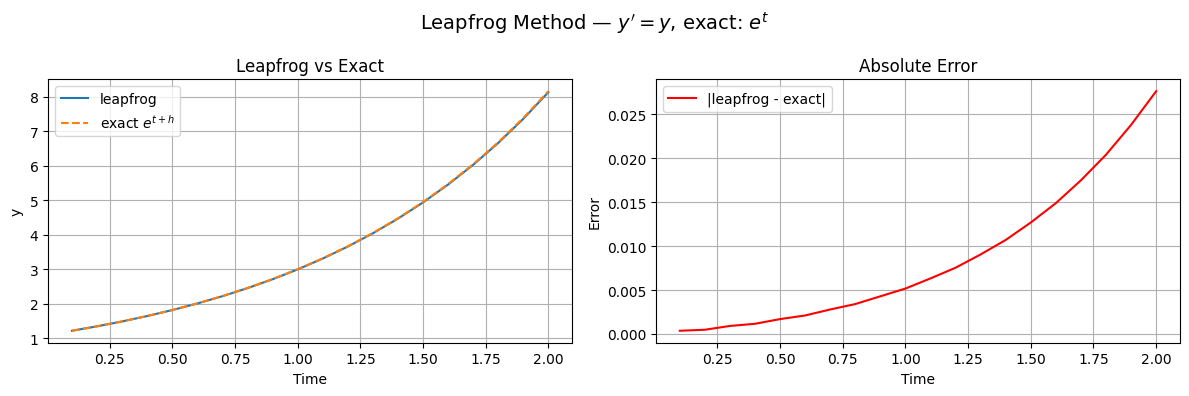

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Leapfrog Method — $y' = y$, exact: $e^t$", fontsize=14)

axes[0].plot(t_lf, y_lf, label="leapfrog")
axes[0].plot(t_lf, y_exact, linestyle="--", label="exact $e^{t+h}$")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("y")
axes[0].set_title("Leapfrog vs Exact")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_lf, err_lf, color="red", label="|leapfrog - exact|")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Error")
axes[1].set_title("Absolute Error")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## RK4 Method — $y' = -y$, exact: $e^{-t}$

Runs RK4 on $y' = -y$ for parts (a) $h_1=0.2$, (b) $h_2=0.1$, and (c/d) adaptive step $h_0$ computed from a Richardson-style error estimate with tolerance $\varepsilon = 10^{-7}$.

In [35]:
from simple_ode_RK4 import run_simulation as run_rk4

rk4 = run_rk4()
print(f"h0 (adaptive step size) = {rk4['h0']:.6e}")

h0 (adaptive step size) = 4.677612e-07


Prints tabular results (time, RK4 value, exact value) for parts (a), (b), and (c)/(d).

In [36]:
print(f"The results of part (a) with h1={rk4['part_a']['h']}")
print(f"{'time':>14} {'rk4':>13} {'exact':>13}")
for t, y, e in zip(rk4["part_a"]["time"], rk4["part_a"]["rk4"], rk4["part_a"]["exact"]):
    print(f"{t:.6f} {y:.11f} {e:.11f}")

print()
print(f"The results of part (b) with h2={rk4['part_b']['h']}")
for t, y, e in zip(rk4["part_b"]["time"], rk4["part_b"]["rk4"], rk4["part_b"]["exact"]):
    print(f"{t:.6f} {y:.11f} {e:.11f}")

print()
h0 = rk4["h0"]
print(f"h0: {h0:.11f}")
print(f"The results of part (c) and the confirmation of part(d) with h0={h0:.11f}")
for t, y, e in zip(rk4["part_c"]["time"], rk4["part_c"]["rk4"], rk4["part_c"]["exact"]):
    print(f"{t:.13f} {y:.11f} {e:.11f}")

The results of part (a) with h1=0.2
          time           rk4         exact
0.500000 0.49658686880 0.60653065971
0.700000 0.40657222238 0.49658530379

The results of part (b) with h2=0.1
0.500000 0.54881168581 0.60653065971
0.600000 0.49658539376 0.54881163609
0.700000 0.44932908622 0.49658530379

h0: 0.00000046776
The results of part (c) and the confirmation of part(d) with h0=0.00000046776
0.5000000000000 0.60653037600 0.60653065971
